# Function 4

<b> Description of the Sample Application:</b> Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions. 



In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [8]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
y       = np.load(output_file)

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", y.shape)
print("Outputs:\n", y)
print()

print(f"y Range: [: {y.min()}, {y.max()}]")
best_idx   = np.argmax(y)
print(f"Best point: x = {X[best_idx]}, y = {y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['y'] = y
print("Data Frame:\n", df)


Input  Shape: (30, 4)
Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.335

# Data Exploration

In [10]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4          y
count  30.000000  30.000000  30.000000  30.000000  30.000000
mean    0.542872   0.477129   0.465693   0.474096 -17.238587
std     0.294007   0.308910   0.261618   0.292412   7.137959
min     0.037825   0.006250   0.042186   0.081517 -32.625660
25%     0.258744   0.150459   0.223273   0.215885 -21.578590
50%     0.601918   0.499909   0.445999   0.499451 -16.040082
75%     0.787653   0.749126   0.708686   0.758504 -12.745906
max     0.985622   0.919592   0.939178   0.999483  -4.025542


In [11]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
y      0
dtype: int64


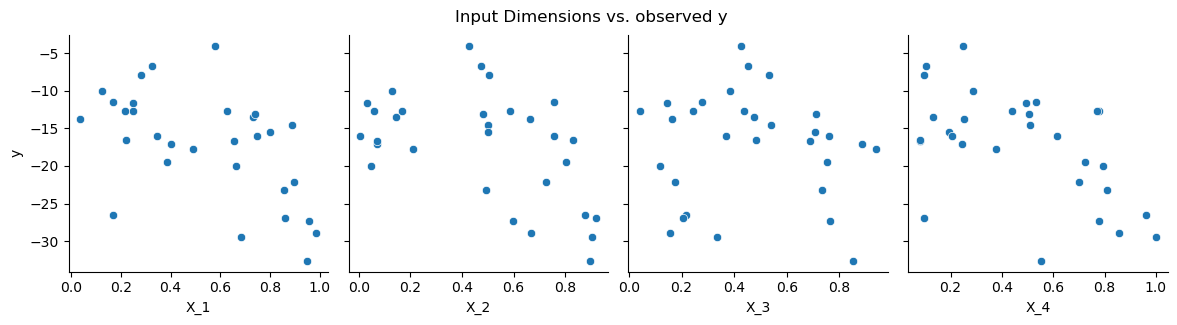

In [16]:
# Pairwise Scatter Plot, showing relationship of y for each input
sns.pairplot(df, y_vars = ['y'], x_vars = ['X_1', 'X_2', 'X_3', 'X_4'], height = 3)
plt.suptitle("Input Dimensions vs. observed y", y = 1.05)
plt.show()

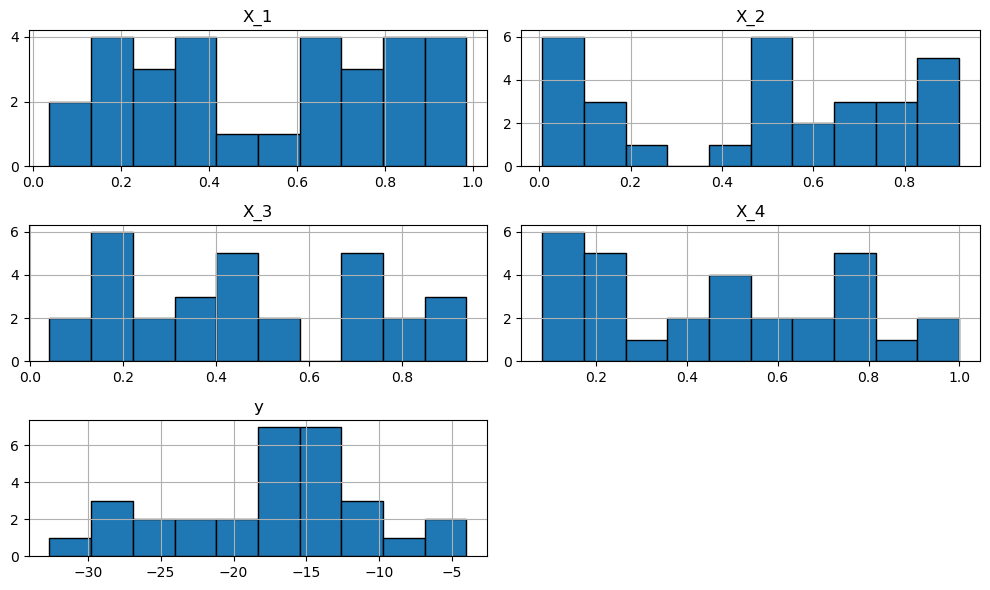

In [17]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [19]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    print(f" corr({lab}, y) = {corr}")

Correlation of each input with y:

 corr(X_1, y) = -0.5398881553680579
 corr(X_2, y) = -0.4848087062668058
 corr(X_3, y) = -0.08479378700450893
 corr(X_4, y) = -0.5321154130707685


<Axes: >

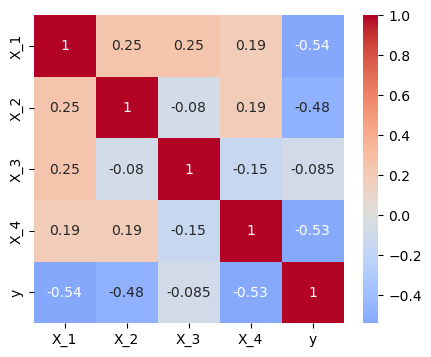

In [20]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

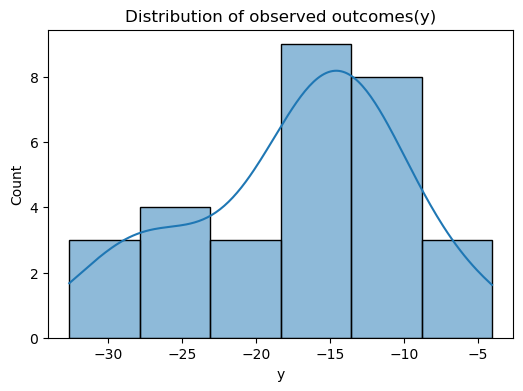

In [21]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['y'], kde = True)
plt.title("Distribution of observed outcomes(y)")
plt.show()

# Initialize Gaussian Process

In [27]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [30]:
# Train the model

gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.01**2 * RBF(length_scale=[0.75, 0.666, 0.756, 0.721]) + WhiteKernel(noise_level=1e-06)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [34]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 4))

mu, std      = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.3839786  0.38351485 0.34014711 0.4452459 ]
Predicted Mean(μ): -1.442484e+00
Predicted Std (σ): 6.674486e-01
UCB Score: 2.261375e-01


# Perform Visualisation

# Portal Submission 

In [38]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}"
print("Points to be submitted(Week 1):", submission_str)
print()

Points to be submitted(Week 1): 0.383979-0.383515-0.340147-0.445246

